
<div align="center">

# 🧠💚 STRESS TRAJECTORY PREDICTION
## *A Machine Learning Approach to Mental Health Risk Assessment*al

---

<img src="https://img.shields.io/badge/Mental%20Health-Matters-green?style=for-the-badge&logo=heart&logoColor=white" alt="Mental Health Matters"/>
<img src="https://img.shields.io/badge/AI%20for-Good-blue?style=for-the-badge&logo=robot&logoColor=white" alt="AI for Good"/>
<img src="https://img.shields.io/badge/Early-Intervention-orange?style=for-the-badge&logo=shield&logoColor=white" alt="Early Intervention"/>

</div>

---


- **Dataset:** Mental Health Dataset
- **Dataset Link:** https://www.kaggle.com/datasets/bhavikjikadara/mental-health-dataset
- **Goal:** Predict whether a person is **At Risk** or **Not At Risk** of growing stress
- **Problem Type:** **Binary Classification**
- **Target Variable:** `Stress_Risk`
- **Primary Metric:** **Recall**

### Target Rule Used
- `Yes` → **At Risk**
- `No` → **Not At Risk**

---
## 💡 Why This Matters for Mental Health

🔹 **1 in 5** adults experience mental health challenges each year  
🔹 **Stress** is the #1 trigger for anxiety and depression  

---
### Why Recall is prioritized
In mental health screening, missing someone who may need support is worse than making an extra check-in.

| Error Type | Real-World Impact |
|------------|------------------|
| **False Negative** ❌ | Missed at-risk person → No intervention → Potential crisis |
| **False Positive** ⚡ | Extra check-in → Minor inconvenience → Still helpful |

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, make_scorer
from scipy.stats import chi2_contingency

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


## 1. Load Dataset

In [2]:

BASE_DIR = Path(".")
DATA_PATH = BASE_DIR / "Mental Health Dataset.csv"
MODELS_DIR = BASE_DIR / "models"
MODELS_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (292364, 17)


,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


## 2. Understand the Data

In [3]:

print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nOriginal Growing_Stress distribution:")
print(df["Growing_Stress"].value_counts(dropna=False))


Timestamp                  object
Gender                     object
Country                    object
Occupation                 object
self_employed              object
family_history             object
treatment                  object
Days_Indoors               object
Growing_Stress             object
Changes_Habits             object
Mental_Health_History      object
Mood_Swings                object
Coping_Struggles           object
Work_Interest              object
Social_Weakness            object
mental_health_interview    object
care_options               object
dtype: object

Missing values:
Timestamp                     0
Gender                        0
Country                       0
Occupation                    0
self_employed              5202
family_history                0
treatment                     0
Days_Indoors                  0
Growing_Stress                0
Changes_Habits                0
Mental_Health_History         0
Mood_Swings                   0
Coping_

## 3. Create Binary Target

In [4]:

df["Stress_Risk"] = df["Growing_Stress"].map({"Yes": "At Risk", "No": "Not At Risk"})
before = len(df)
df = df.dropna(subset=["Stress_Risk"]).copy()
print(f"Removed {before - len(df)} 'Maybe' rows")
print(df["Stress_Risk"].value_counts())


Removed 99985 'Maybe' rows
Stress_Risk
At Risk        99653
Not At Risk    92726
Name: count, dtype: int64


## 4. Exploratory Data Analysis

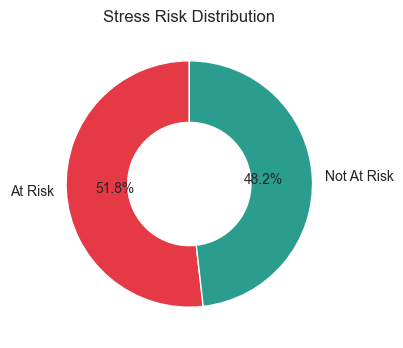

Insight: After removing 'Maybe', the problem becomes a clean binary classification task.


In [5]:

counts = df["Stress_Risk"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
ax.pie(counts.values, labels=counts.index, autopct="%1.1f%%", startangle=90,
       colors=["#E63946", "#2A9D8F"], wedgeprops={"width": 0.5})
ax.set_title("Stress Risk Distribution")
plt.show()

print("Insight: After removing 'Maybe', the problem becomes a clean binary classification task.")


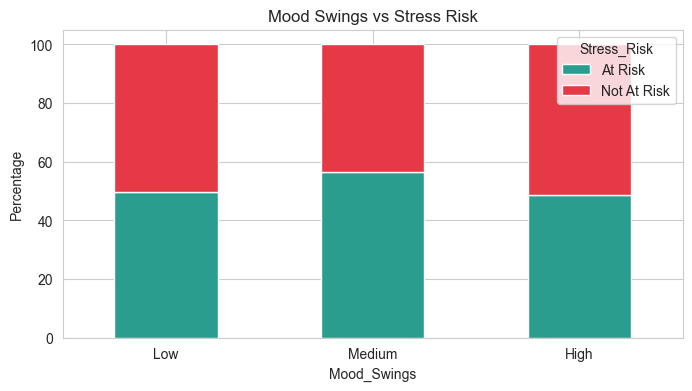

Insight: Higher mood swings are associated with higher stress risk.


In [6]:

ct = pd.crosstab(df["Mood_Swings"], df["Stress_Risk"], normalize="index") * 100
ct = ct.reindex(["Low", "Medium", "High"])

ct.plot(kind="bar", stacked=True, figsize=(8, 4), color=["#2A9D8F", "#E63946"])
plt.title("Mood Swings vs Stress Risk")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

print("Insight: Higher mood swings are associated with higher stress risk.")


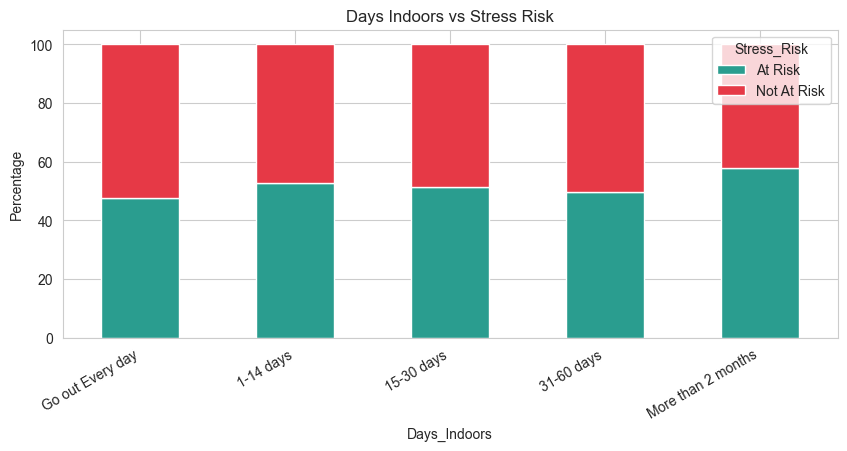

Insight: More time indoors appears linked with higher stress risk.


In [7]:

order = ["Go out Every day", "1-14 days", "15-30 days", "31-60 days", "More than 2 months"]
ct = pd.crosstab(df["Days_Indoors"], df["Stress_Risk"], normalize="index") * 100
ct = ct.reindex([x for x in order if x in ct.index])

ct.plot(kind="bar", stacked=True, figsize=(10, 4), color=["#2A9D8F", "#E63946"])
plt.title("Days Indoors vs Stress Risk")
plt.ylabel("Percentage")
plt.xticks(rotation=30, ha="right")
plt.show()

print("Insight: More time indoors appears linked with higher stress risk.")


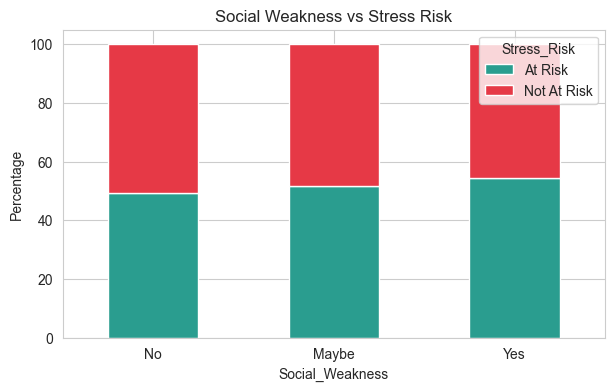

Insight: Social weakness is associated with a higher share of at-risk cases.


In [8]:

ct = pd.crosstab(df["Social_Weakness"], df["Stress_Risk"], normalize="index") * 100
ct = ct.reindex([x for x in ["No", "Maybe", "Yes"] if x in ct.index])

ct.plot(kind="bar", stacked=True, figsize=(7, 4), color=["#2A9D8F", "#E63946"])
plt.title("Social Weakness vs Stress Risk")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

print("Insight: Social weakness is associated with a higher share of at-risk cases.")


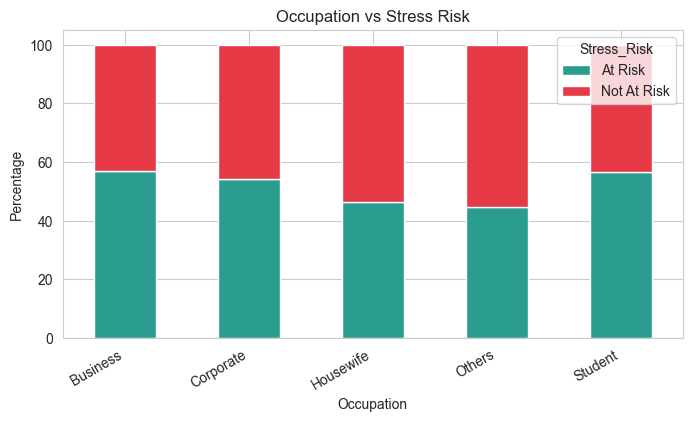

Insight: Different occupation groups show different stress-risk patterns.


In [9]:

ct = pd.crosstab(df["Occupation"], df["Stress_Risk"], normalize="index") * 100

ct.plot(kind="bar", stacked=True, figsize=(8, 4), color=["#2A9D8F", "#E63946"])
plt.title("Occupation vs Stress Risk")
plt.ylabel("Percentage")
plt.xticks(rotation=30, ha="right")
plt.show()

print("Insight: Different occupation groups show different stress-risk patterns.")


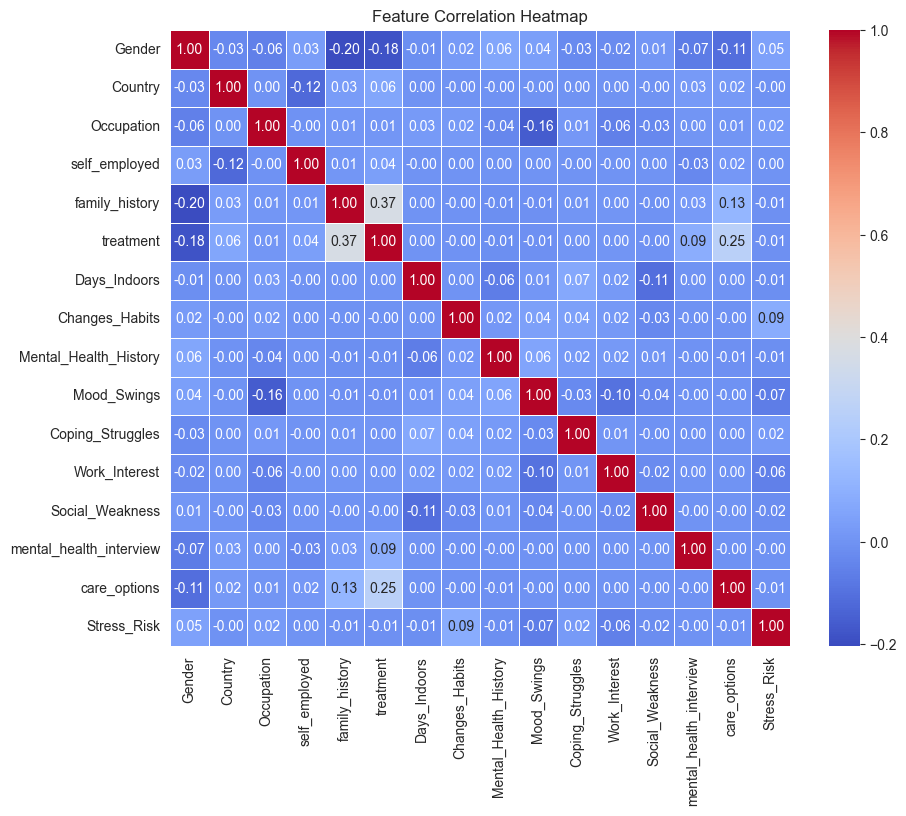

Insight: Mood_Swings, Days_Indoors, and Social_Weakness show meaningful association patterns with stress risk.


In [10]:

df_corr = df.drop(columns=["Timestamp", "Growing_Stress"], errors="ignore").copy()
for col in df_corr.columns:
    if df_corr[col].dtype == "object":
        df_corr[col] = LabelEncoder().fit_transform(df_corr[col].astype(str))

corr = df_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

print("Insight: Mood_Swings, Days_Indoors, and Social_Weakness show meaningful association patterns with stress risk.")


## 5. Data Cleaning

In [11]:

df_clean = df.copy()
df_clean = df_clean.drop(columns=["Timestamp", "Growing_Stress", "Country"], errors="ignore")
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

for col in df_clean.select_dtypes(include="object").columns:
    df_clean[col] = df_clean[col].str.strip()

print("Clean shape:", df_clean.shape)


Clean shape: (24066, 15)


## 6. Feature Selection

In [12]:

chi_results = {}
for col in df_clean.columns:
    if col != "Stress_Risk":
        contingency = pd.crosstab(df_clean[col], df_clean["Stress_Risk"])
        chi2_stat, p_val, _, _ = chi2_contingency(contingency)
        chi_results[col] = p_val

chi_df = pd.DataFrame({
    "Feature": list(chi_results.keys()),
    "p_value": list(chi_results.values())
}).sort_values("p_value")

chi_df


,Feature,p_value
6,Changes_Habits,2.308717e-41
5,Days_Indoors,2.124421e-29
10,Work_Interest,3.203368e-28
1,Occupation,1.175609e-25
8,Mood_Swings,3.239320e-21
0,Gender,7.306837e-20
11,Social_Weakness,5.318455e-08
7,Mental_Health_History,2.774961e-03
9,Coping_Struggles,8.796138e-03
2,self_employed,4.058800e-02


In [13]:

selected_features = [
    "Mood_Swings",
    "Days_Indoors",
    "Occupation",
    "Social_Weakness",
    "Changes_Habits",
    "Gender",
    "Work_Interest",
    "Mental_Health_History"
]
selected_features


['Mood_Swings',
 'Days_Indoors',
 'Occupation',
 'Social_Weakness',
 'Changes_Habits',
 'Gender',
 'Work_Interest',
 'Mental_Health_History']

## 7. Preprocessing

In [29]:

df_final = df_clean[selected_features + ["Stress_Risk"]].copy()

encoders = {}
for col in df_final.columns:
    if df_final[col].dtype == "object":
        encoders[col] = LabelEncoder()
        df_final[col] = encoders[col].fit_transform(df_final[col].astype(str))

X = df_final.drop("Stress_Risk", axis=1)
y = df_final["Stress_Risk"]
feature_columns = list(X.columns)
class_labels = list(encoders["Stress_Risk"].classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Classes:", class_labels)



Train shape: (19252, 8)
Test shape: (4814, 8)
Classes: ['At Risk', 'Not At Risk']


## 8. Model 1 - Decision Tree

In [30]:

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree")
print("Accuracy :", round(accuracy_score(y_test, y_pred_dt), 4))
print("Precision:", round(precision_score(y_test, y_pred_dt), 4))
print("Recall   :", round(recall_score(y_test, y_pred_dt), 4))
print("F1       :", round(f1_score(y_test, y_pred_dt), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))


Decision Tree
Accuracy : 0.99
Precision: 0.9956
Recall   : 0.9833
F1       : 0.9894

Confusion Matrix:
 [[2527   10]
 [  38 2239]]


## 9. Model 2 - Categorical Naive Bayes

In [31]:

nb_model = CategoricalNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes")
print("Accuracy :", round(accuracy_score(y_test, y_pred_nb), 4))
print("Precision:", round(precision_score(y_test, y_pred_nb), 4))
print("Recall   :", round(recall_score(y_test, y_pred_nb), 4))
print("F1       :", round(f1_score(y_test, y_pred_nb), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))


Naive Bayes
Accuracy : 0.5762
Precision: 0.5592
Recall   : 0.4914
F1       : 0.5231

Confusion Matrix:
 [[1655  882]
 [1158 1119]]


## 10. Hyperparameter Tuning

In [32]:

dt_params = {
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring="recall",
    n_jobs=-1
)
dt_grid.fit(X_train, y_train)
dt_tuned = dt_grid.best_estimator_
y_pred_dt_tuned = dt_tuned.predict(X_test)

print("Best DT params:", dt_grid.best_params_)
print("Tuned DT Recall:", round(recall_score(y_test, y_pred_dt_tuned), 4))


Best DT params: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Tuned DT Recall: 0.9833


In [33]:

nb_params = {"alpha": [0.1, 0.5, 1.0, 2.0, 5.0]}

nb_grid = GridSearchCV(
    CategoricalNB(),
    nb_params,
    cv=5,
    scoring="recall",
    n_jobs=-1
)
nb_grid.fit(X_train, y_train)
nb_tuned = nb_grid.best_estimator_
y_pred_nb_tuned = nb_tuned.predict(X_test)

print("Best NB params:", nb_grid.best_params_)
print("Tuned NB Recall:", round(recall_score(y_test, y_pred_nb_tuned), 4))


Best NB params: {'alpha': 0.1}
Tuned NB Recall: 0.4914


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Train-test split options
splits = [0.10, 0.20, 0.25, 0.30]

results = []

for split in splits:

    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=split,
        random_state=42,
        stratify=y
    )

    # Train model
    nb_model = CategoricalNB()
    nb_model.fit(X_train, y_train)

    # Predict
    y_pred = nb_model.predict(X_test)

    # Store results
    results.append({
        "Train %": int((1-split)*100),
        "Test %": int(split*100),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

# Convert to table
results_df = pd.DataFrame(results)

# Display table
results_df.round(4)

,Train %,Test %,Accuracy,Precision,Recall,F1 Score
0,90,10,0.5754,0.5581,0.4934,0.5238
1,80,20,0.5762,0.5592,0.4914,0.5231
2,75,25,0.5828,0.5680,0.4930,0.5278
3,70,30,0.5747,0.5571,0.4930,0.5231


## 11. Decision Tree Visualization

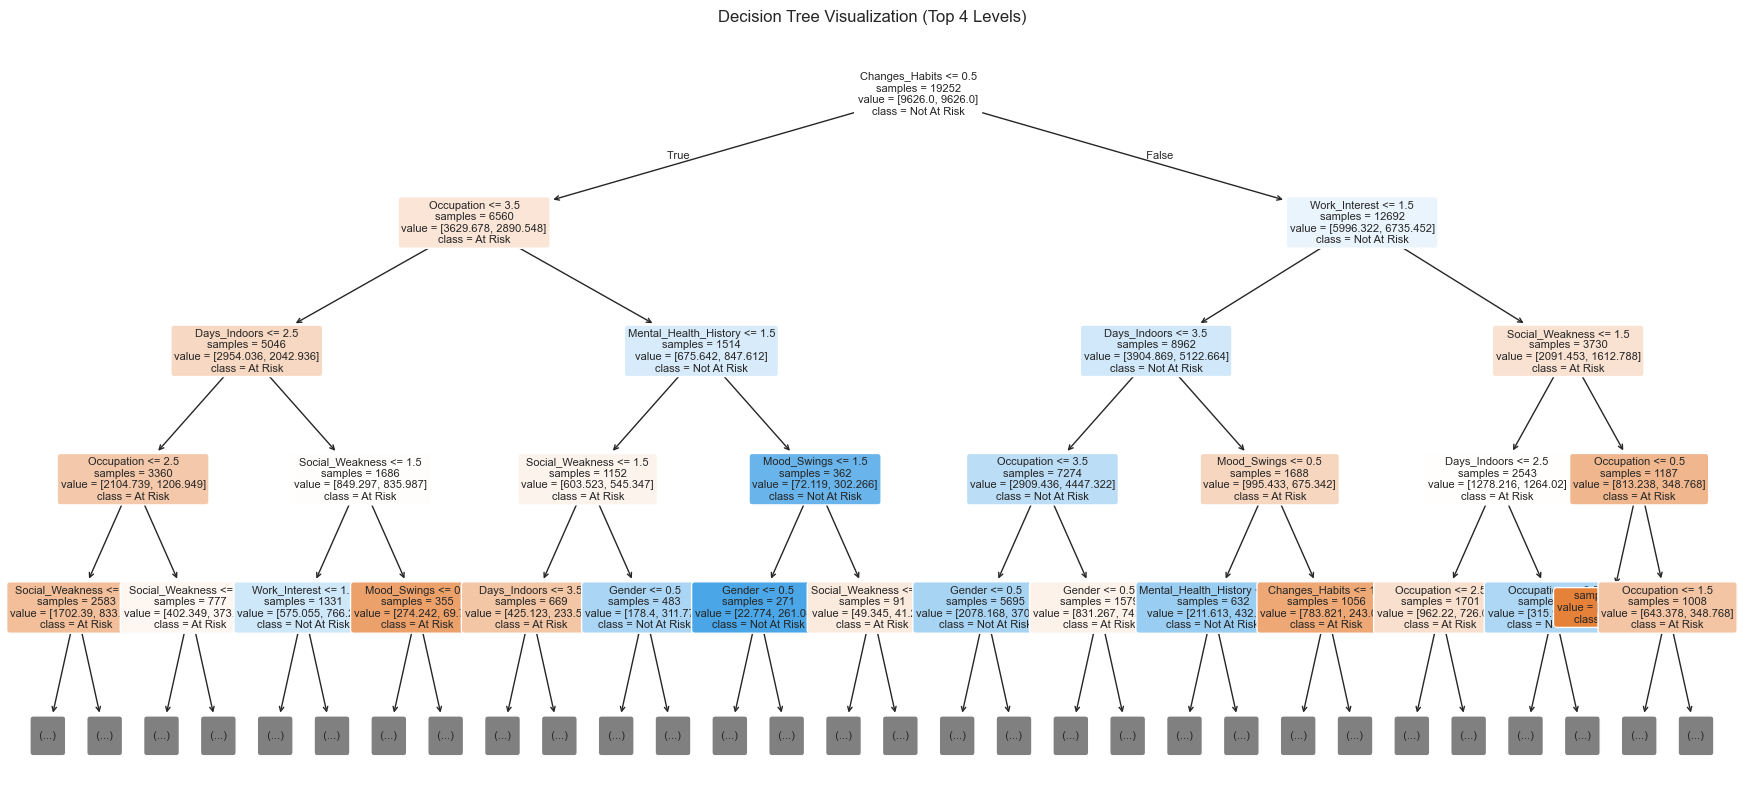

In [19]:

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt_tuned,
    feature_names=feature_columns,
    class_names=class_labels,
    filled=True,
    rounded=True,
    max_depth=4,
    fontsize=8,
    ax=ax,
    impurity=False
)
plt.title("Decision Tree Visualization (Top 4 Levels)")
plt.show()


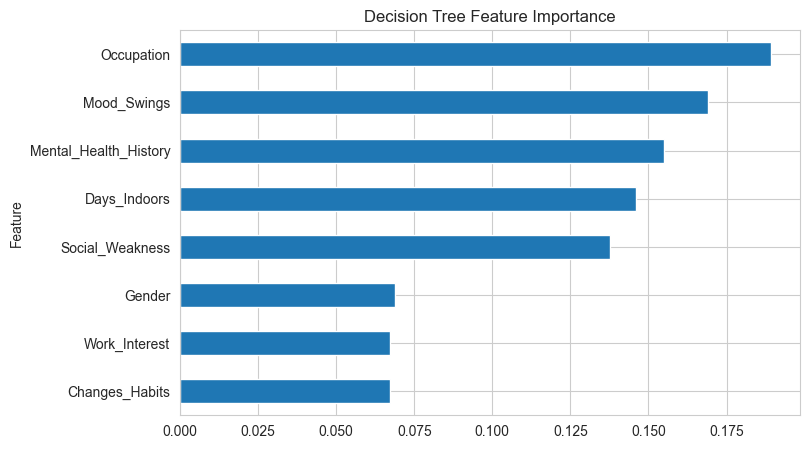

In [20]:

importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": dt_tuned.feature_importances_
}).sort_values("Importance", ascending=True)

importance_df.plot(kind="barh", x="Feature", y="Importance", figsize=(8, 5), legend=False)
plt.title("Decision Tree Feature Importance")
plt.show()


## 12. Cross-Validation

In [21]:

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
recall_scorer = make_scorer(recall_score)

dt_cv_scores = cross_val_score(
    DecisionTreeClassifier(class_weight="balanced", random_state=42),
    X, y, cv=cv5, scoring=recall_scorer
)

nb_cv_scores = cross_val_score(
    CategoricalNB(),
    X, y, cv=cv5, scoring=recall_scorer
)

print("DT CV Recall:", dt_cv_scores.mean().round(4), "+/-", dt_cv_scores.std().round(4))
print("NB CV Recall:", nb_cv_scores.mean().round(4), "+/-", nb_cv_scores.std().round(4))


DT CV Recall: 0.995 +/- 0.0028
NB CV Recall: 0.4827 +/- 0.0055


## 13. Final Model Comparison

In [22]:

comparison_df = pd.DataFrame({
    "Model": ["Decision Tree", "Naive Bayes"],
    "Accuracy": [accuracy_score(y_test, y_pred_dt_tuned), accuracy_score(y_test, y_pred_nb_tuned)],
    "Precision": [precision_score(y_test, y_pred_dt_tuned), precision_score(y_test, y_pred_nb_tuned)],
    "Recall": [recall_score(y_test, y_pred_dt_tuned), recall_score(y_test, y_pred_nb_tuned)],
    "F1": [f1_score(y_test, y_pred_dt_tuned), f1_score(y_test, y_pred_nb_tuned)]
})

comparison_df.sort_values("Recall", ascending=False)


,Model,Accuracy,Precision,Recall,F1
0,Decision Tree,0.988990,0.985590,0.991217,0.988395
1,Naive Bayes,0.577482,0.562791,0.478261,0.517094


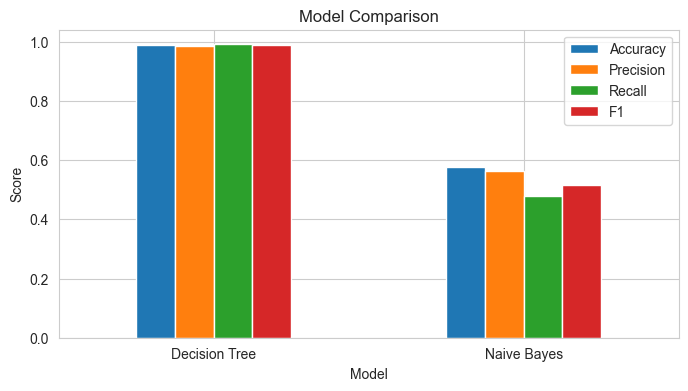

Best model based on Recall: Decision Tree


In [23]:

comparison_df.set_index("Model").plot(kind="bar", figsize=(8, 4))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

best_model_name = comparison_df.sort_values("Recall", ascending=False).iloc[0]["Model"]
print("Best model based on Recall:", best_model_name)


## 14. Save Models and Artifacts for Streamlit

In [24]:

joblib.dump(dt_tuned, MODELS_DIR / "decision_tree_model.pkl")
joblib.dump(nb_tuned, MODELS_DIR / "naive_bayes_model.pkl")
joblib.dump(encoders, MODELS_DIR / "encoders.pkl")
joblib.dump(encoders, MODELS_DIR / "nb_encoders.pkl")
joblib.dump(feature_columns, MODELS_DIR / "feature_columns.pkl")
joblib.dump(feature_columns, MODELS_DIR / "nb_feature_columns.pkl")

results_dict = {
    "dt_accuracy": accuracy_score(y_test, y_pred_dt_tuned),
    "dt_precision": precision_score(y_test, y_pred_dt_tuned),
    "dt_recall": recall_score(y_test, y_pred_dt_tuned),
    "dt_f1": f1_score(y_test, y_pred_dt_tuned),
    "dt_cm": confusion_matrix(y_test, y_pred_dt_tuned).tolist(),
    "dt_cv_mean": dt_cv_scores.mean(),
    "dt_cv_std": dt_cv_scores.std(),
    "nb_accuracy": accuracy_score(y_test, y_pred_nb_tuned),
    "nb_precision": precision_score(y_test, y_pred_nb_tuned),
    "nb_recall": recall_score(y_test, y_pred_nb_tuned),
    "nb_f1": f1_score(y_test, y_pred_nb_tuned),
    "nb_cm": confusion_matrix(y_test, y_pred_nb_tuned).tolist(),
    "nb_cv_mean": nb_cv_scores.mean(),
    "nb_cv_std": nb_cv_scores.std(),
    "best_model": best_model_name,
    "class_labels": class_labels,
    "features_used": feature_columns,
    "dataset_size": len(df_final),
    "maybe_removed": True,
    "split_random_state": 80,
    "smote_used": False
}
joblib.dump(results_dict, MODELS_DIR / "model_results.pkl")

print("Artifacts saved to:", MODELS_DIR.resolve())


Artifacts saved to: /Users/peaceabikoye/Desktop/Winter 2026/Artificial Intelligence/Project folder/Machine-Learning-Project/models
